In [1]:
# Movie Review Classification using NLP
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

# Download Required NLTK Files
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [2]:
# Step 1 : Collect Movie Review Data
# ==========================================

data = {
    "Review": [
        "The movie was amazing with outstanding acting.",
        "Excellent storyline and brilliant direction.",
        "The songs were beautiful and entertaining.",
        "The movie was boring and too long.",
        "Poor acting and weak storyline.",
        "Fantastic visual effects and great performances.",
        "The ending was disappointing.",
        "Wonderful movie. Highly recommended.",
        "Average movie with decent acting.",
        "Terrible script and bad direction."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display Dataset
print("Movie Review Dataset")
print(df)

Movie Review Dataset
                                             Review
0    The movie was amazing with outstanding acting.
1      Excellent storyline and brilliant direction.
2        The songs were beautiful and entertaining.
3                The movie was boring and too long.
4                   Poor acting and weak storyline.
5  Fantastic visual effects and great performances.
6                     The ending was disappointing.
7              Wonderful movie. Highly recommended.
8                 Average movie with decent acting.
9                Terrible script and bad direction.


In [3]:
# Step 2 : Preprocess Review Text
# ==========================================

stop_words = set(stopwords.words('english'))

def Clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply Cleaning
df["Cleaned_Review"] = df["Review"].apply(Clean_text)

print("\nCleaned Reviews\n")
print(df["Cleaned_Review"])



Cleaned Reviews

0               movie amazing outstanding acting
1        excellent storyline brilliant direction
2                   songs beautiful entertaining
3                              movie boring long
4                     poor acting weak storyline
5    fantastic visual effects great performances
6                           ending disappointing
7             wonderful movie highly recommended
8                    average movie decent acting
9                  terrible script bad direction
Name: Cleaned_Review, dtype: object


In [4]:
# Step 3 : Build Sentiment Classification Model
# ==========================================

sia = SentimentIntensityAnalyzer()

def analyze_sentiment(review):

    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

# Apply Sentiment Classification
df["Sentiment"] = df["Cleaned_Review"].apply(analyze_sentiment)

print("\nSentiment Classification\n")
print(df[["Review", "Sentiment"]])



Sentiment Classification

                                             Review Sentiment
0    The movie was amazing with outstanding acting.  Positive
1      Excellent storyline and brilliant direction.  Positive
2        The songs were beautiful and entertaining.  Positive
3                The movie was boring and too long.  Negative
4                   Poor acting and weak storyline.  Negative
5  Fantastic visual effects and great performances.  Positive
6                     The ending was disappointing.  Negative
7              Wonderful movie. Highly recommended.  Positive
8                 Average movie with decent acting.   Neutral
9                Terrible script and bad direction.  Negative


In [5]:
# Step 4 : Analyze Audience Opinions
# ==========================================

all_words = " ".join(df["Cleaned_Review"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))

negative_reviews = df[df["Sentiment"] == "Negative"]

negative_words = " ".join(negative_reviews["Cleaned_Review"])

negative_word_list = negative_words.split()

negative_freq = Counter(negative_word_list)

print("\nCommon Negative Opinion Keywords")
print(negative_freq.most_common(10))

print("\nFinal Processed Dataset\n")
print(df)



Top 10 Common Keywords
[('movie', 4), ('acting', 3), ('storyline', 2), ('direction', 2), ('amazing', 1), ('outstanding', 1), ('excellent', 1), ('brilliant', 1), ('songs', 1), ('beautiful', 1)]

Common Negative Opinion Keywords
[('movie', 1), ('boring', 1), ('long', 1), ('poor', 1), ('acting', 1), ('weak', 1), ('storyline', 1), ('ending', 1), ('disappointing', 1), ('terrible', 1)]

Final Processed Dataset

                                             Review  \
0    The movie was amazing with outstanding acting.   
1      Excellent storyline and brilliant direction.   
2        The songs were beautiful and entertaining.   
3                The movie was boring and too long.   
4                   Poor acting and weak storyline.   
5  Fantastic visual effects and great performances.   
6                     The ending was disappointing.   
7              Wonderful movie. Highly recommended.   
8                 Average movie with decent acting.   
9                Terrible script and bad

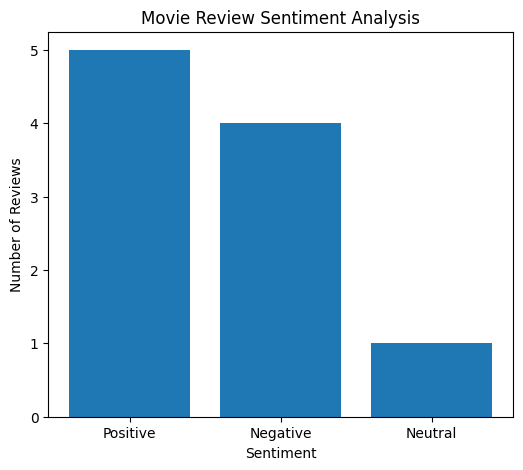

In [6]:
# Step 5 : Visualize Sentiment Results
# ==========================================

sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Movie Review Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()


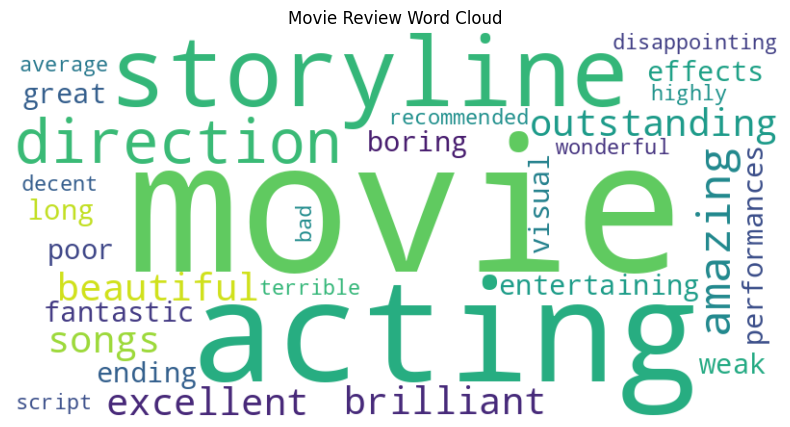

In [7]:
# Word Cloud
# ==========================================

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Movie Review Word Cloud")
plt.show()


In [8]:
# Audience Opinion Report
# ==========================================

print("\nAudience Opinion Report")
print("--------------------------------")

positive_count = len(df[df["Sentiment"] == "Positive"])
negative_count = len(df[df["Sentiment"] == "Negative"])
neutral_count = len(df[df["Sentiment"] == "Neutral"])

print("Total Reviews :", len(df))
print("Positive Reviews :", positive_count)
print("Negative Reviews :", negative_count)
print("Neutral Reviews :", neutral_count)

print("\nCommon Positive Opinions:")
print("- Excellent acting")
print("- Good storyline")
print("- Great direction")
print("- Amazing visual effects")

print("\nCommon Negative Opinions:")
print("- Poor acting")
print("- Weak storyline")
print("- Bad direction")
print("- Disappointing ending")

print("\nTop Negative Keywords:")
for word, count in negative_freq.most_common(5):
    print(f"{word} : {count}")

print("\nRecommendation:")
print("1. Improve story development.")
print("2. Focus on better screenplay and direction.")
print("3. Enhance character development.")
print("4. Maintain strong acting performances.")
print("5. Improve the overall entertainment value.")


Audience Opinion Report
--------------------------------
Total Reviews : 10
Positive Reviews : 5
Negative Reviews : 4
Neutral Reviews : 1

Common Positive Opinions:
- Excellent acting
- Good storyline
- Great direction
- Amazing visual effects

Common Negative Opinions:
- Poor acting
- Weak storyline
- Bad direction
- Disappointing ending

Top Negative Keywords:
movie : 1
boring : 1
long : 1
poor : 1
acting : 1

Recommendation:
1. Improve story development.
2. Focus on better screenplay and direction.
3. Enhance character development.
4. Maintain strong acting performances.
5. Improve the overall entertainment value.
